In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot style settings for clean, consistent visuals
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

In [2]:
df = pd.read_csv('22. messy_sales_data.csv')

In [3]:
# --- Missing values ---
df['City'] = df['City'].fillna('Unknown')
df['PaymentMode'] = df['PaymentMode'].fillna(df['PaymentMode'].mode()[0])

# --- Duplicates ---
df = df.drop_duplicates()
dup_mask = df['OrderID'].duplicated(keep='first')
df.loc[dup_mask, 'OrderID'] = df.loc[dup_mask, 'OrderID'] + '_DUP' + df.loc[dup_mask].groupby('OrderID').cumcount().astype(str)

# --- String cleaning ---
df['CustomerName'] = df['CustomerName'].str.strip().str.title()

df['City'] = df['City'].str.strip().str.lower()
city_map = {
    'mumbai': 'Mumbai', 'bombay': 'Mumbai',
    'delhi': 'Delhi', 'new delhi': 'Delhi',
    'bangalore': 'Bangalore', 'bengaluru': 'Bangalore', 'banglore': 'Bangalore',
    'chennai': 'Chennai', 'madras': 'Chennai',
    'kolkata': 'Kolkata', 'calcutta': 'Kolkata',
    'hyderabad': 'Hyderabad',
    'pune': 'Pune', 'poona': 'Pune',
    'ahmedabad': 'Ahmedabad', 'amdavad': 'Ahmedabad',
    'jaipur': 'Jaipur',
    'lucknow': 'Lucknow',
    'unknown': 'Unknown'
}
df['City'] = df['City'].map(city_map).fillna(df['City'].str.title())

df['Category'] = df['Category'].str.strip().str.lower().str.rstrip('s')
df['Category'] = df['Category'].replace({'electronic': 'electronics'})
df['Category'] = df['Category'].str.title()

payment_map = {
    'credit card': 'Credit Card', 'cc': 'Credit Card', 'credit_card': 'Credit Card',
    'debit card': 'Debit Card', 'dc': 'Debit Card',
    'upi': 'UPI',
    'cod': 'Cash on Delivery', 'cash on delivery': 'Cash on Delivery',
    'net banking': 'Net Banking', 'netbanking': 'Net Banking', 'net_banking': 'Net Banking'
}
df['PaymentMode'] = df['PaymentMode'].str.strip().str.lower().map(payment_map)

# --- Numeric cleaning ---
df['Price'] = df['Price'].astype(str).str.replace(r'[₹,]', '', regex=True).str.replace('Rs.', '', regex=False).str.strip()
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').abs()

df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').abs()

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df.loc[(df['Rating'] < 0) | (df['Rating'] > 5), 'Rating'] = np.nan

df['CustomerAge'] = pd.to_numeric(df['CustomerAge'], errors='coerce')
df.loc[(df['CustomerAge'] < 10) | (df['CustomerAge'] > 100), 'CustomerAge'] = np.nan

# --- Fill remaining numeric NaNs ---
df['Price'] = df['Price'].fillna(df['Price'].median())
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median()).astype(int)
df['Rating'] = df['Rating'].fillna(df.groupby('Category')['Rating'].transform('mean'))
df['CustomerAge'] = df['CustomerAge'].fillna(df['CustomerAge'].median()).astype(int)

# --- Dates ---
df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce', dayfirst=True)
df['OrderDate'] = df['OrderDate'].fillna(df['OrderDate'].median())

# --- Rename to snake_case ---
df = df.rename(columns={
    'OrderID': 'order_id', 'CustomerID': 'customer_id', 'CustomerName': 'customer_name',
    'City': 'city', 'Category': 'category', 'PaymentMode': 'payment_mode',
    'Price': 'price', 'Quantity': 'quantity', 'DiscountPct': 'discount_pct',
    'Rating': 'rating', 'OrderDate': 'order_date', 'CustomerAge': 'customer_age',
    'Email': 'email', 'Phone': 'phone', 'ReviewText': 'review_text'
})

# --- Feature engineering needed for plots ---
df['total_price'] = (df['price'] * df['quantity']).round(2)
df['discount_amount'] = (df['total_price'] * df['discount_pct'] / 100).round(2)
df['final_price'] = (df['total_price'] - df['discount_amount']).round(2)

df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_month_name'] = df['order_date'].dt.month_name()
df['order_weekday'] = df['order_date'].dt.day_name()

bins = [0, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels)

print("Cleaned data shape:", df.shape)
df.head()

Cleaned data shape: (105519, 23)


C:\Users\amitm\AppData\Local\Temp\ipykernel_4700\3645382254.py:61: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['OrderDate'] = pd.to_datetime(df['OrderDate'], errors='coerce', dayfirst=True)


,order_id,customer_id,customer_name,city,category,payment_mode,price,quantity,discount_pct,rating,...,phone,review_text,total_price,discount_amount,final_price,order_year,order_month,order_month_name,order_weekday,age_group
0,ORD51058,CUST04879,Chaitanya Mane,Bangalore,Grocery,Net Banking,904.48,3,10,3.3,...,9454663439,Packaging was bad,2713.44,271.34,2442.10,2023,4,April,Monday,26-35
1,ORD70248,CUST00177,Siddharth Sha,Delhi,Sport,Net Banking,1823.76,4,20,5.0,...,NaN,great service,7295.04,1459.01,5836.03,2024,1,January,Tuesday,36-50
2,ORD43804,CUST04537,Nathaniel Chatterjee,Chennai,Electronics,UPI,770.67,1,0,4.9,...,9573975601,Okayish product,770.67,0.00,770.67,2024,1,January,Tuesday,36-50
3,ORD46367,CUST07605,Pranit Contractor,Jaipur,Clothing,Cash on Delivery,2028.06,1,0,2.9,...,9235766629,NaN,2028.06,0.00,2028.06,2024,1,January,Tuesday,36-50
4,ORD32922,CUST03180,Hemang Chakraborty,Ahmedabad,Furniture,Credit Card,604.00,4,10,3.7,...,9731250657,Superb!!! fast delivery,2416.00,241.60,2174.40,2024,1,January,Tuesday,36-50


In [5]:
df.columns

Index(['order_id', 'customer_id', 'customer_name', 'city', 'category',
       'payment_mode', 'price', 'quantity', 'discount_pct', 'rating',
       'order_date', 'customer_age', 'email', 'phone', 'review_text',
       'total_price', 'discount_amount', 'final_price', 'order_year',
       'order_month', 'order_month_name', 'order_weekday', 'age_group'],
      dtype='str')

## 3. Bivariate Analysis

Bivariate analysis looks at the **relationship between two variables** — for example, how price varies across categories, or how rating relates to revenue.

### 3.1 Category vs Final Price — Boxplot

C:\Users\amitm\AppData\Local\Temp\ipykernel_4700\946014676.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='final_price', palette='Set2')


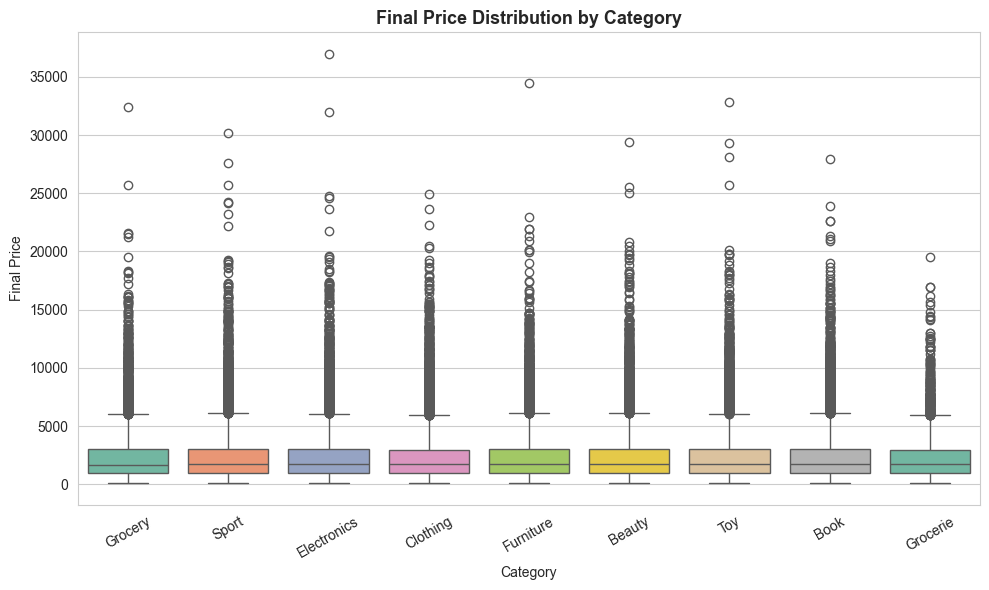

In [4]:
# A boxplot shows the spread and outliers of final_price within each category,
# helping us compare price ranges across categories at a glance
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='category', y='final_price', palette='Set2')
plt.title('Final Price Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Final Price')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.2 City vs Total Revenue — Bar Chart

In [8]:
df.groupby('city')['price'].mean()

city
Ahmedabad    1194.147951
Bangalore    1189.181721
Chennai      1195.016112
Delhi        1192.988212
Hyderabad    1187.616269
Jaipur       1176.814163
Kolkata      1200.202351
Lucknow      1178.428834
Mumbai       1175.537423
Pune         1201.821645
Unknown      1196.151889
Name: price, dtype: float64

In [10]:
df.groupby('city')['final_price'].sum()

city
Ahmedabad    24468254.09
Bangalore    24513890.90
Chennai      24968286.44
Delhi        24185276.80
Hyderabad    24475460.12
Jaipur       24266217.92
Kolkata      24898609.55
Lucknow      24000182.34
Mumbai       24733651.80
Pune         24404213.09
Unknown       4819831.99
Name: final_price, dtype: float64

In [13]:
city_revenue.index

Index(['Chennai', 'Kolkata', 'Mumbai', 'Bangalore', 'Hyderabad', 'Ahmedabad',
       'Pune', 'Jaipur', 'Delhi', 'Lucknow', 'Unknown'],
      dtype='str', name='city')

In [14]:
city_revenue.values

array([24968286.44, 24898609.55, 24733651.8 , 24513890.9 , 24475460.12,
       24468254.09, 24404213.09, 24266217.92, 24185276.8 , 24000182.34,
        4819831.99])

C:\Users\amitm\AppData\Local\Temp\ipykernel_4700\3450925081.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='flare')


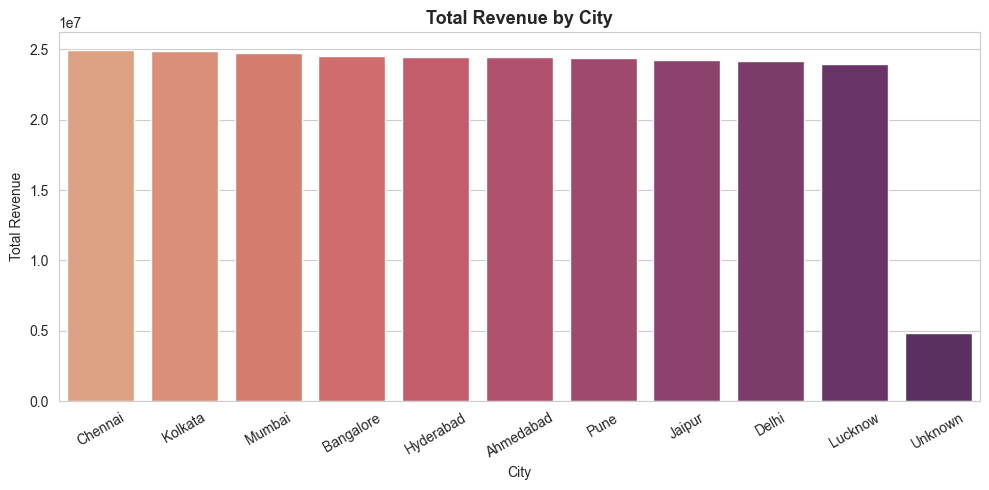

In [15]:
# Total revenue generated by each city, sorted for easy comparison
city_revenue = df.groupby('city')['final_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='flare')
plt.title('Total Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.3 Payment Mode vs Average Order Value — Bar Chart

In [16]:
# Does the payment method used relate to how much customers typically spend?
avg_order_by_payment = df.groupby('payment_mode')['final_price'].mean().sort_values(ascending=False)

In [17]:
avg_order_by_payment

payment_mode
Debit Card          2382.300805
UPI                 2380.769155
Credit Card         2367.335074
Net Banking         2352.791658
Cash on Delivery    2348.222571
Name: final_price, dtype: float64

C:\Users\amitm\AppData\Local\Temp\ipykernel_4700\341371632.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_order_by_payment.index, y=avg_order_by_payment.values, palette='rocket')


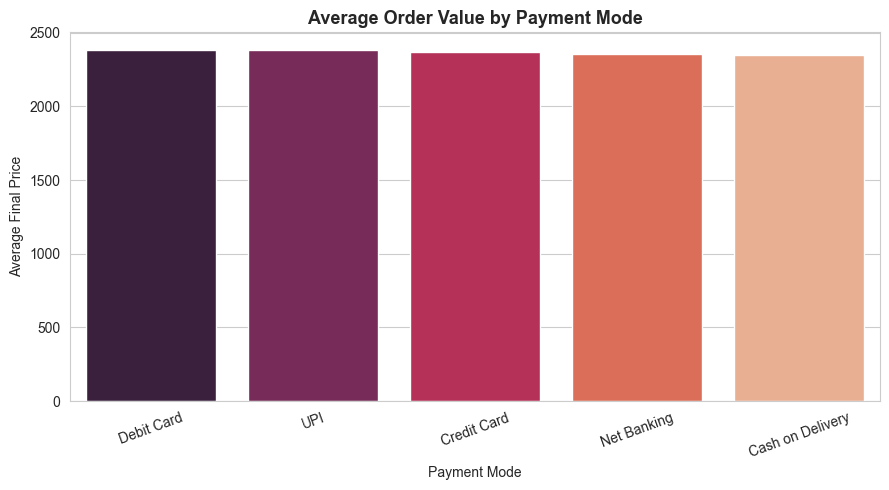

In [18]:
plt.figure(figsize=(9, 5))
sns.barplot(x=avg_order_by_payment.index, y=avg_order_by_payment.values, palette='rocket')
plt.title('Average Order Value by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Average Final Price')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 3.4 Monthly Revenue Trend — Line Chart

In [19]:
monthly_revenue = df.groupby(['order_year', 'order_month'])['final_price'].sum().reset_index()

In [20]:
monthly_revenue

,order_year,order_month,final_price
0,2023,1,2.092637e+06
1,2023,2,1.648678e+06
2,2023,3,2.155350e+06
3,2023,4,1.969884e+06
4,2023,5,1.932309e+06
5,2023,6,1.970155e+06
6,2023,7,2.255457e+06
7,2023,8,1.984711e+06
8,2023,9,2.068556e+06
9,2023,10,2.000655e+06


In [26]:
# A line chart is the clearest way to see revenue trend over time (month by month)
monthly_revenue = df.groupby(['order_year', 'order_month'])['final_price'].sum().reset_index()
monthly_revenue['period'] = (monthly_revenue['order_year'].astype(str) + '-' +
                              monthly_revenue['order_month'].astype(str).str.zfill(2))
monthly_revenue = monthly_revenue.sort_values('period')

In [27]:
monthly_revenue

,order_year,order_month,final_price,period
0,2023,1,2.092637e+06,2023-01
1,2023,2,1.648678e+06,2023-02
2,2023,3,2.155350e+06,2023-03
3,2023,4,1.969884e+06,2023-04
4,2023,5,1.932309e+06,2023-05
5,2023,6,1.970155e+06,2023-06
6,2023,7,2.255457e+06,2023-07
7,2023,8,1.984711e+06,2023-08
8,2023,9,2.068556e+06,2023-09
9,2023,10,2.000655e+06,2023-10


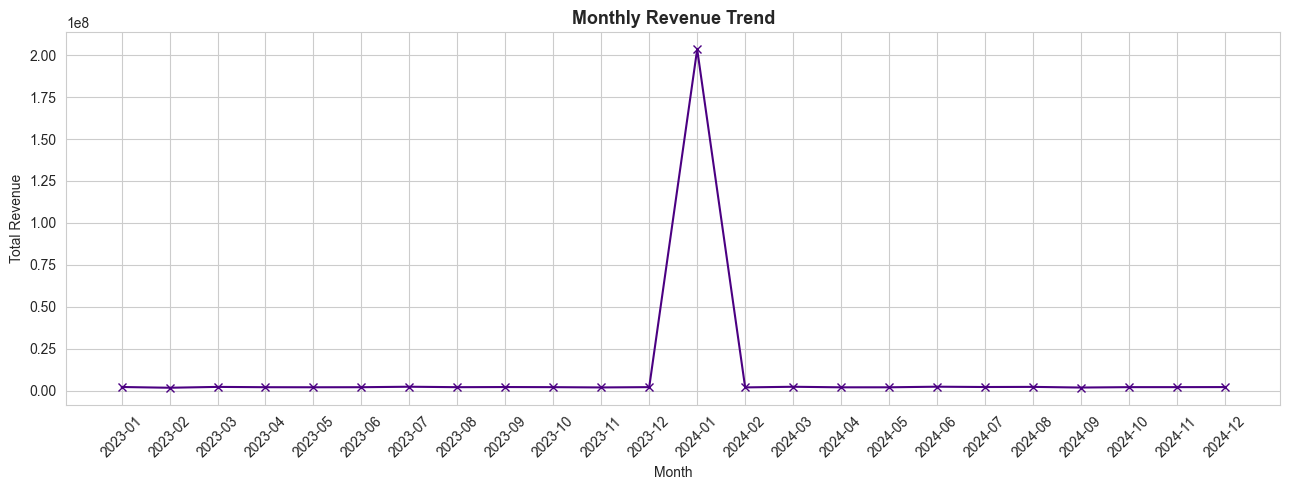

In [29]:
plt.figure(figsize=(13, 5))
plt.plot(monthly_revenue['period'], monthly_revenue['final_price'], marker='x', color='indigo')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
a- 20
a - 30
a - 50
a - 70
b- 20
b - 30
b - 50
b - 70


In [25]:
df.groupby(["city", "payment_mode"])["quantity"].sum()

city       payment_mode    
Ahmedabad  Cash on Delivery    4368
           Credit Card         4452
           Debit Card          4339
           Net Banking         4357
           UPI                 5054
Bangalore  Cash on Delivery    4420
           Credit Card         4316
           Debit Card          4387
           Net Banking         4599
           UPI                 5187
Chennai    Cash on Delivery    4353
           Credit Card         4529
           Debit Card          4602
           Net Banking         4452
           UPI                 5176
Delhi      Cash on Delivery    4282
           Credit Card         4273
           Debit Card          4501
           Net Banking         4427
           UPI                 4936
Hyderabad  Cash on Delivery    4388
           Credit Card         4306
           Debit Card          4509
           Net Banking         4665
           UPI                 4903
Jaipur     Cash on Delivery    4406
           Credit Card         4271


In [21]:
df.columns

Index(['order_id', 'customer_id', 'customer_name', 'city', 'category',
       'payment_mode', 'price', 'quantity', 'discount_pct', 'rating',
       'order_date', 'customer_age', 'email', 'phone', 'review_text',
       'total_price', 'discount_amount', 'final_price', 'order_year',
       'order_month', 'order_month_name', 'order_weekday', 'age_group'],
      dtype='str')

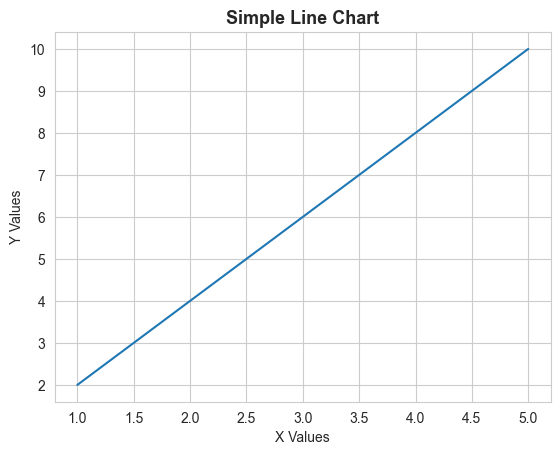

In [30]:
x = [1, 2, 3, 4, 5]                 # Independent variable (e.g., days, hours)
y = [2, 4, 6, 8, 10]                # Dependent variable (e.g., sales, growth)

plt.plot(x, y)                      # Plots a line connecting (x, y) pairs
plt.title("Simple Line Chart")      # Chart title (makes chart readable)
plt.xlabel("X Values")              # Label for X-axis
plt.ylabel("Y Values")              # Label for Y-axis
plt.show()    

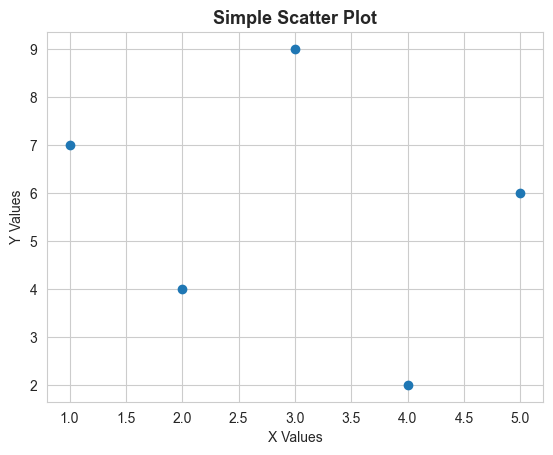

In [31]:

x = [1, 2, 3, 4, 5]                 # X: First variable (e.g., test score)
y = [7, 4, 9, 2, 6]                 # Y: Second variable (e.g., hours studied)

plt.scatter(x, y)                   # Shows each (x, y) as a dot (no line)
plt.title("Simple Scatter Plot")
plt.xlabel("X Values")
plt.ylabel("Y Values")
plt.show()

In [33]:
data = pd.read_csv("F:\\Dataset\\messy_vehicle_sales_data.xls")

In [34]:
data.shape

(2000000, 54)

In [35]:
data.columns

Index(['Transaction_ID', 'Sale_Date', 'Manufacturer', 'Model',
       'Production_Year', 'Vehicle_Type', 'Fuel_Type', 'Engine_Size',
       'Horsepower', 'Torque', 'Acceleration_0_60mph', 'Top_Speed',
       'Fuel_Efficiency', 'CO2_Emissions', 'Price_USD',
       'Production_Cost_Estimate', 'Market_Segment', 'Region_Sold',
       'Country_Sold', 'Dealer_Name', 'Customer_Age_Group', 'Customer_Gender',
       'Payment_Type', 'Financing_Interest_Rate', 'Trade_In_Value',
       'Warranty_Years', 'Safety_Rating', 'Autonomous_Level',
       'Infotainment_System', 'Connectivity_Features', 'Seating_Capacity',
       'Cargo_Volume', 'Resale_Value_Estimate', 'Recall_History',
       'Battery_Range_km', 'Supply_Chain_Delay_Days',
       'Market_Share_Percentage', 'R&D_Investment_MUSD', 'Brand_Loyalty_Score',
       'Body_Style', 'Drivetrain_Type', 'Transmission_Type', 'Number_of_Gears',
       'Wheelbase_inches', 'Curb_Weight_kg', 'Towing_Capacity_kg',
       'Interior_Material', 'Exterior_Color'

In [36]:
data.head()

,Transaction_ID,Sale_Date,Manufacturer,Model,Production_Year,Vehicle_Type,Fuel_Type,Engine_Size,Horsepower,Torque,...,Curb_Weight_kg,Towing_Capacity_kg,Interior_Material,Exterior_Color,Number_of_Airbags,Software_Update_Capability,Regional_Tax_Rate,Charging_Infrastructure_Score,Tariff_Impact_Pct,Consumer_Demand_Index
0,TXN0,12/07/2021,Ford,ModelX,2017.0,@@@,??,NaN,150 hp,NaN,...,NaN,2000.0,Vinyl,Red,6.0,No,10.0,NaN,NaN,999.0
1,TXN1,NaN,Ford,ModelX,2019.0,123,??,2.0L,200HP,280 newton,...,NaN,2000.0,NaN,Blue,4.0,Yes,NaN,NaN,5.0,NaN
2,TXN2##,12/07/2021,BMW,Civic,2019.0,Sedan,Petrol,3.5L,220 horsepower,300Nm,...,1800kg,1000.0,Fabric,??,NaN,No,NaN,NaN,5.0,999.0
3,TXN3,"July 12, 2021",Hyundai,Corolla,NaN,Coupe,NaN,NaN,220 horsepower,280 newton,...,1500,1000.0,Fabric,NaN,8.0,Yes,10.0,70.0,999.0,NaN
4,TXN4ERR,2021-07-12,Hyundai,Civic,2019.0,SUV,Electric,NaN,150 hp,300Nm,...,NaN,2000.0,Leather,Red,4.0,No,5.0,50.0,15.0,50.0


In [37]:
df.dropna()

,order_id,customer_id,customer_name,city,category,payment_mode,price,quantity,discount_pct,rating,...,phone,review_text,total_price,discount_amount,final_price,order_year,order_month,order_month_name,order_weekday,age_group
0,ORD51058,CUST04879,Chaitanya Mane,Bangalore,Grocery,Net Banking,904.48,3,10,3.300000,...,9454663439,Packaging was bad,2713.44,271.34,2442.10,2023,4,April,Monday,26-35
2,ORD43804,CUST04537,Nathaniel Chatterjee,Chennai,Electronics,UPI,770.67,1,0,4.900000,...,9573975601,Okayish product,770.67,0.00,770.67,2024,1,January,Tuesday,36-50
4,ORD32922,CUST03180,Hemang Chakraborty,Ahmedabad,Furniture,Credit Card,604.00,4,10,3.700000,...,9731250657,Superb!!! fast delivery,2416.00,241.60,2174.40,2024,1,January,Tuesday,36-50
6,ORD33523,CUST02017,Tara Nagarajan,Delhi,Clothing,Credit Card,1349.31,1,0,3.265271,...,9759730420,delivery was late,1349.31,0.00,1349.31,2024,1,January,Tuesday,26-35
9,ORD59831,CUST07512,Kevin Amble,Mumbai,Beauty,Net Banking,876.46,3,20,3.261052,...,9810381180,worst product ever received damaged item,2629.38,525.88,2103.50,2024,1,January,Tuesday,50+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106569,ORD92081,CUST02778,Jalsa Rastogi,Kolkata,Electronics,Net Banking,1854.93,4,0,2.800000,...,9486328773,Product as described,7419.72,0.00,7419.72,2024,1,January,Tuesday,26-35
106570,ORD49057,CUST01636,Max Om,Chennai,Furniture,Debit Card,1961.37,4,0,5.000000,...,9123457578,Amazing quality!!!,7845.48,0.00,7845.48,2023,6,June,Sunday,26-35
106571,ORD60012,CUST01826,Charan Manne,Pune,Toy,Cash on Delivery,1468.22,2,20,3.300000,...,9226831132,Good product loved it,2936.44,587.29,2349.15,2024,1,January,Tuesday,36-50
106572,ORD78050,CUST04033,Isaiah Wali,Delhi,Furniture,Debit Card,414.94,2,10,3.300000,...,9758098090,Not satisfied poor quality,829.88,82.99,746.89,2024,1,January,Tuesday,18-25


In [ ]:
Peter Piper picked a peck of pickled peppers.

Six slippery snails slid slowly seaward.

Thirty-three thirsty thieves thought throughout Thursday.

Pad kid poured curd pulled cod.

She sells seashells by the seashore.